# Arabic Dialect Detection with AraBERT

Fine-tunes **`aubmindlab/bert-base-arabertv02`** on the **IADD dataset** for 6-class Arabic dialect region classification.

| Code | Region | Countries |
|------|--------|-----------|
| MGH | Maghrebi | Algeria, Morocco, Tunisia |
| LEV | Levantine | Syria, Palestine, Jordan, Lebanon |
| EGY | Egyptian | Egypt |
| IRQ | Iraqi | Iraq |
| GLF | Gulf | Gulf states |
| general | General | Mixed |

> **Before running:** Enable GPU via *Runtime → Change runtime type → T4 GPU*

## 1. Setup

In [2]:
%%capture
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn requests

In [3]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU. Enable via Runtime → Change runtime type → T4 GPU")

PyTorch: 2.10.0+cu128
GPU available: True
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Imports & Configuration

In [4]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
import json, os, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
import torch.nn as nn
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print("Imports done.")

Imports done.


In [5]:
MODEL_NAME         = "aubmindlab/bert-base-arabertv02"
MODEL_DISPLAY_NAME = "AraBERT"
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 3
LR         = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 3. Load IADD Dataset

In [6]:
def load_iadd():
    urls = [
        "https://raw.githubusercontent.com/JihadZa/IADD/main/IADD.json",
        "https://raw.githubusercontent.com/JihadZa/IADD/master/IADD.json",
    ]
    for url in urls:
        try:
            print(f"Trying: {url}")
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            data = r.json()
            print(f"Successfully loaded {len(data):,} samples")
            return data
        except Exception as e:
            print(f"  Failed: {e}")

    print("\nAutomatic download failed. Upload IADD.json manually:")
    print("  from google.colab import files")
    print("  uploaded = files.upload()")
    print("  data = json.loads(list(uploaded.values())[0])")
    return None

data = load_iadd()
df = pd.DataFrame(data)
print(f"Columns: {list(df.columns)}")
df.head()

Trying: https://raw.githubusercontent.com/JihadZa/IADD/main/IADD.json
Successfully loaded 135,804 samples
Columns: ['Sentence', 'Region', 'DataSource', 'Country']


,Sentence,Region,DataSource,Country
0,: وش فيك تسألني إذا كنت غالي؟ غالي وتسوى من ...,GLF,DART,NA
1,روان بن حسين مستحيل ما ادز شي بسناب حتى لو ما...,GLF,DART,NA
2,: ما نسيتك بالدعا والأرض جفاف، وشلون أبنساك و...,GLF,DART,NA
3,: فارس_البقميk_محب أطيب من الطيب واصل الطيب ...,GLF,DART,NA
4,شوفو والله ابوها كشخه وصغير احس واضحه الفلوس م...,GLF,DART,NA


## 4. Exploratory Data Analysis

=== Dataset Overview ===
Shape: (135804, 4)

Region distribution:
Region
LEV        87573
MGH        33996
GLF         6682
EGY         4837
general     2500
IRQ          216
Name: count, dtype: int64

Country distribution:
Country
Syria        44972
Palestine    17855
NA           16441
Algeria      14426
Tunisia      11998
Lebanon      10829
Morocco       7213
Jordan        7017
Egypt         4837
Iraq           216
Name: count, dtype: int64


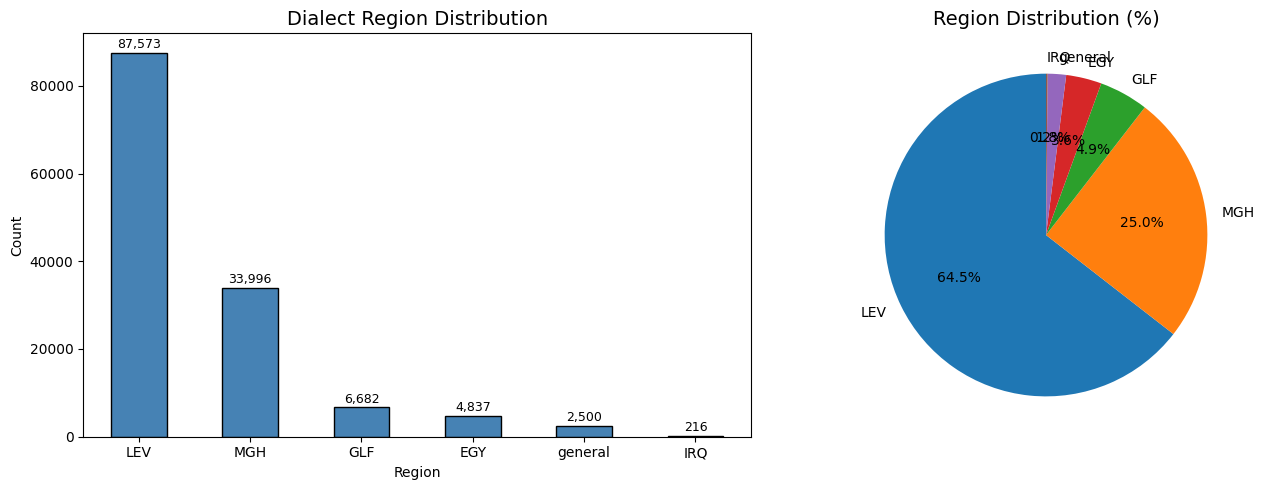


Average word count by region:
         mean  median   max
Region                     
EGY      24.0    13.0  1303
GLF      15.7    10.0  7530
IRQ      12.7    12.0    30
LEV      13.0     9.0   690
MGH       7.6     5.0  1164
general   9.0     6.0   154


In [7]:
print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"\nRegion distribution:")
print(df["Region"].value_counts())
print(f"\nCountry distribution:")
print(df["Country"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df["Region"].value_counts()

counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Dialect Region Distribution", fontsize=14)
axes[0].set_xlabel("Region"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for bar, cnt in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=9)

counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Region Distribution (%)", fontsize=14); axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig("dialect_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Text length analysis
df["word_count"] = df["Sentence"].astype(str).apply(lambda x: len(x.split()))
print("\nAverage word count by region:")
print(df.groupby("Region")["word_count"].agg(["mean","median","max"]).round(1))

## 5. Preprocessing & Label Encoding

In [8]:
# Drop missing / empty
df = df.dropna(subset=["Sentence"])
df["Sentence"] = df["Sentence"].astype(str).str.strip()
df = df[df["Sentence"].str.len() > 0].reset_index(drop=True)

# Encode labels
label_names = sorted(df["Region"].unique())
label2id = {l: i for i, l in enumerate(label_names)}
id2label  = {i: l for l, i in label2id.items()}
df["label"] = df["Region"].map(label2id)
NUM_LABELS = len(label2id)

print(f"Label mapping: {label2id}")
print(f"Number of classes: {NUM_LABELS}")
print(f"Total samples after cleaning: {len(df):,}")

Label mapping: {'EGY': 0, 'GLF': 1, 'IRQ': 2, 'LEV': 3, 'MGH': 4, 'general': 5}
Number of classes: 6
Total samples after cleaning: 135,804


## 6. Train / Val / Test Split  (70 / 15 / 15, stratified)

In [9]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"\nTrain class distribution:")
print(train_df["Region"].value_counts())

Train: 95,062 | Val: 20,371 | Test: 20,371

Train class distribution:
Region
LEV        61301
MGH        23797
GLF         4677
EGY         3386
general     1750
IRQ          151
Name: count, dtype: int64


## 7. Tokenizer

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size:,}")

# Quick sanity-check
sample = df["Sentence"].iloc[0]
tokens = tokenizer(sample, max_length=MAX_LEN, truncation=True)
print(f"Sample ({len(tokens['input_ids'])} tokens): {sample[:80]}...")

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer: aubmindlab/bert-base-arabertv02
Vocab size: 64,000
Sample (34 tokens): : وش فيك تسألني إذا كنت غالي؟  غالي وتسوى من غلااتك عيوني   كل  ما تمر  ايامنا  ...


## 8. PyTorch Dataset

In [11]:
class ArabicDialectDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = ArabicDialectDataset(train_df["Sentence"].values, train_df["label"].values, tokenizer, MAX_LEN)
val_ds   = ArabicDialectDataset(val_df["Sentence"].values,   val_df["label"].values,   tokenizer, MAX_LEN)
test_ds  = ArabicDialectDataset(test_df["Sentence"].values,  test_df["label"].values,  tokenizer, MAX_LEN)
print(f"Datasets — Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")

Datasets — Train: 95,062 | Val: 20,371 | Test: 20,371


## 9. Load AraBERT Model

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Total params:     135,197,958
Trainable params: 135,197,958


## 10. Class Weights (handle imbalance)

In [13]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=train_df["label"].values
)
WEIGHT_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(WEIGHT_DEVICE)

print("Class weights (corrects for imbalance):")
for i, (lbl, w) in enumerate(zip(label_names, class_weights)):
    n = (train_df["label"] == i).sum()
    print(f"  {lbl:10s}: weight={w:.3f}  (n={n:,})")

Class weights (corrects for imbalance):
  EGY       : weight=4.679  (n=3,386)
  GLF       : weight=3.388  (n=4,677)
  IRQ       : weight=104.925  (n=151)
  LEV       : weight=0.258  (n=61,301)
  MGH       : weight=0.666  (n=23,797)
  general   : weight=9.054  (n=1,750)


## 11. Custom Weighted Trainer

In [14]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    float(accuracy_score(labels, preds)),
        "f1_weighted": float(f1_score(labels, preds, average="weighted")),
        "f1_macro":    float(f1_score(labels, preds, average="macro")),
    }

## 12. Training

In [16]:
warmup_steps = int(0.1 * (len(train_ds) // BATCH_SIZE) * EPOCHS)
print(f"Warmup steps: {warmup_steps}")

training_args = TrainingArguments(
    output_dir="./arabert_checkpoints",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    warmup_steps=warmup_steps,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    dataloader_num_workers=2,
)

trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

Warmup steps: 891


In [17]:
print("Starting AraBERT fine-tuning...")
print(f"  Model:  {MODEL_NAME}")
print(f"  Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")
print(f"  Train:  {len(train_ds):,} samples")
print("-" * 50)
trainer.train()
print("Training complete.")

Starting AraBERT fine-tuning...
  Model:  aubmindlab/bert-base-arabertv02
  Epochs: 3 | Batch: 32 | LR: 2e-05
  Train:  95,062 samples
--------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.663060,0.720315,0.900839,0.906512,0.689001
2,0.506062,0.807419,0.913357,0.916362,0.692425
3,0.328938,0.816573,0.914290,0.919343,0.724578


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete.


## 13. Evaluation

In [18]:
print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
test_output = trainer.predict(test_ds)
preds       = np.argmax(test_output.predictions, axis=-1)
true_labels = test_output.label_ids

acc  = accuracy_score(true_labels, preds)
f1_w = f1_score(true_labels, preds, average="weighted")
f1_m = f1_score(true_labels, preds, average="macro")

print(f"Accuracy:    {acc:.4f}")
print(f"F1 Weighted: {f1_w:.4f}")
print(f"F1 Macro:    {f1_m:.4f}")
print("\nClassification Report:")
print(classification_report(
    true_labels, preds,
    target_names=[id2label[i] for i in range(NUM_LABELS)]
))

TEST SET EVALUATION


Accuracy:    0.9094
F1 Weighted: 0.9156
F1 Macro:    0.7437

Classification Report:
              precision    recall  f1-score   support

         EGY       0.72      0.79      0.75       726
         GLF       0.71      0.79      0.75      1002
         IRQ       0.78      0.76      0.77        33
         LEV       0.97      0.92      0.95     13136
         MGH       0.92      0.96      0.94      5099
     general       0.23      0.45      0.31       375

    accuracy                           0.91     20371
   macro avg       0.72      0.78      0.74     20371
weighted avg       0.92      0.91      0.92     20371



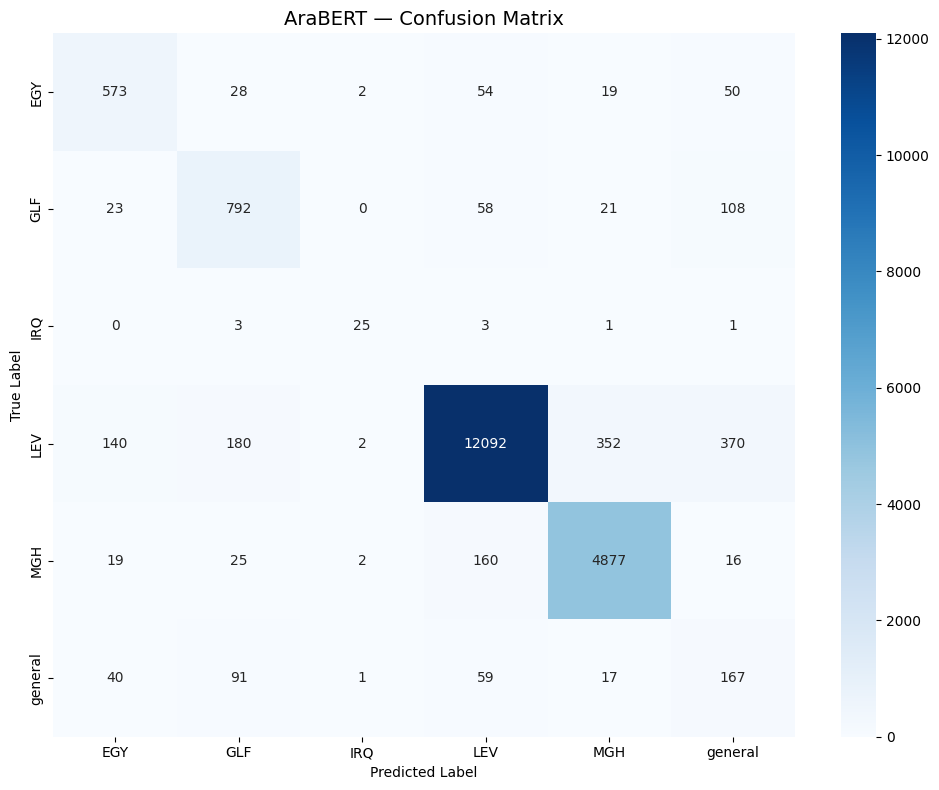

Saved: arabert_confusion_matrix.png


In [19]:
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[id2label[i] for i in range(NUM_LABELS)],
            yticklabels=[id2label[i] for i in range(NUM_LABELS)])
plt.title(f"{MODEL_DISPLAY_NAME} — Confusion Matrix", fontsize=14)
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
fname = MODEL_DISPLAY_NAME.lower().replace(" ", "_") + "_confusion_matrix.png"
plt.savefig(fname, dpi=150)
plt.show()
print(f"Saved: {fname}")

In [20]:
results = {
    "model":       MODEL_DISPLAY_NAME,
    "accuracy":    float(acc),
    "f1_weighted": float(f1_w),
    "f1_macro":    float(f1_m),
    "report":      classification_report(
        true_labels, preds,
        target_names=[id2label[i] for i in range(NUM_LABELS)],
        output_dict=True
    )
}
fname = MODEL_DISPLAY_NAME.lower().replace(" ", "_") + "_results.json"
with open(fname, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to {fname}")
print(f"Summary → Accuracy: {acc:.4f} | F1-W: {f1_w:.4f} | F1-M: {f1_m:.4f}")

Results saved to arabert_results.json
Summary → Accuracy: 0.9094 | F1-W: 0.9156 | F1-M: 0.7437


## 14. Save Model

In [21]:
trainer.save_model("./arabert_model")
tokenizer.save_pretrained("./arabert_model")
print("Model saved to ./arabert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./arabert_model


---

## Part 2 — Country-Level Classification

We now retrain AraBERT to predict the **specific country** instead of the broader region.

| Code | Country | Region |
|------|---------|--------|
| DZ | Algeria | Maghrebi |
| TUN | Tunisia | Maghrebi |
| MAR | Morocco | Maghrebi |
| EGY | Egypt | Egyptian |
| IRQ | Iraq | Iraqi |
| SYR | Syria | Levantine |
| JOR | Jordan | Levantine |
| PSE | Palestine | Levantine |
| LBN | Lebanon | Levantine |

> Entries with `Country = "NA"` (Gulf + General, ~9,182 samples) are excluded — they have no specific country label.

**This uses a fresh AraBERT model** with 9 output classes instead of 6. Everything else (tokenizer, training setup, evaluation) is identical so results are directly comparable.

Samples with known country: 119,363
Dropped (NA country):       16,441

Country distribution:
Country
Syria        44972
Palestine    17855
Algeria      14426
Tunisia      11998
Lebanon      10829
Morocco       7213
Jordan        7017
Egypt         4837
Iraq           216
Name: count, dtype: int64


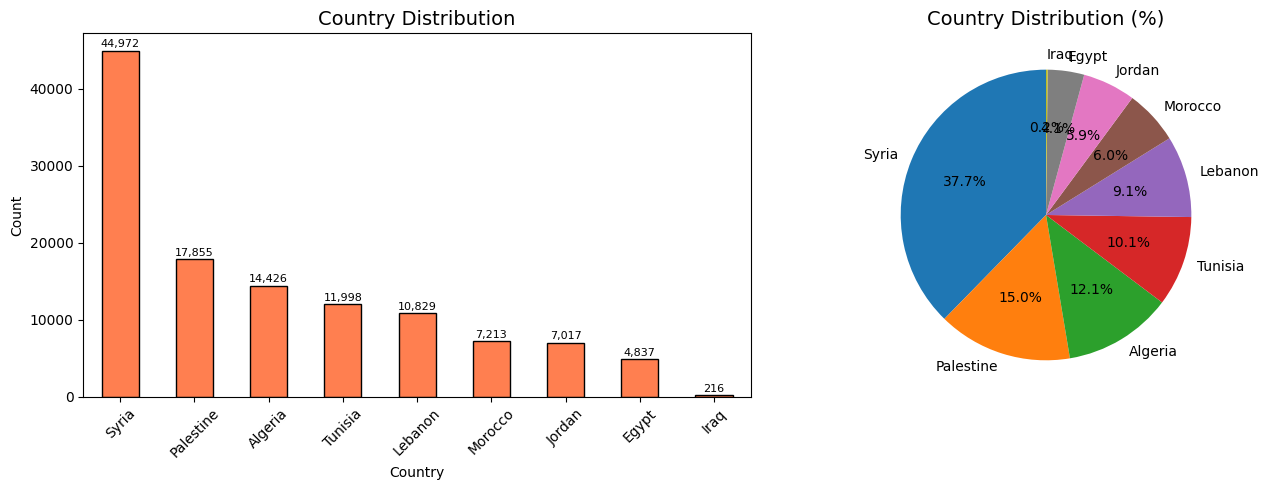

In [22]:
# Filter out "NA" entries — Gulf and General have no specific country
df_country = df[df["Country"] != "NA"].copy().reset_index(drop=True)

print(f"Samples with known country: {len(df_country):,}")
print(f"Dropped (NA country):       {len(df) - len(df_country):,}")
print(f"\nCountry distribution:")
print(df_country["Country"].value_counts())

# EDA for countries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
country_counts = df_country["Country"].value_counts()

country_counts.plot(kind="bar", ax=axes[0], color="coral", edgecolor="black")
axes[0].set_title("Country Distribution", fontsize=14)
axes[0].set_xlabel("Country"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
for bar, cnt in zip(axes[0].patches, country_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=8)

country_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Country Distribution (%)", fontsize=14); axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig("country_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Encode country labels
country_names = sorted(df_country["Country"].unique())
c_label2id = {l: i for i, l in enumerate(country_names)}
c_id2label  = {i: l for l, i in c_label2id.items()}
df_country["c_label"] = df_country["Country"].map(c_label2id)
NUM_COUNTRY_LABELS = len(c_label2id)

print(f"Country label mapping: {c_label2id}")
print(f"Number of country classes: {NUM_COUNTRY_LABELS}")

# Stratified split (70 / 15 / 15)
c_train_df, c_temp_df = train_test_split(
    df_country, test_size=0.30, random_state=SEED, stratify=df_country["c_label"]
)
c_val_df, c_test_df = train_test_split(
    c_temp_df, test_size=0.50, random_state=SEED, stratify=c_temp_df["c_label"]
)
print(f"\nSplit → Train: {len(c_train_df):,} | Val: {len(c_val_df):,} | Test: {len(c_test_df):,}")
print(f"\nTrain country distribution:")
print(c_train_df["Country"].value_counts())

Country label mapping: {'Algeria': 0, 'Egypt': 1, 'Iraq': 2, 'Jordan': 3, 'Lebanon': 4, 'Morocco': 5, 'Palestine': 6, 'Syria': 7, 'Tunisia': 8}
Number of country classes: 9

Split → Train: 83,554 | Val: 17,904 | Test: 17,905

Train country distribution:
Country
Syria        31480
Palestine    12499
Algeria      10098
Tunisia       8399
Lebanon       7580
Morocco       5049
Jordan        4912
Egypt         3386
Iraq           151
Name: count, dtype: int64


In [24]:
# Reuse same tokenizer and ArabicDialectDataset class (already defined above)
c_train_ds = ArabicDialectDataset(c_train_df["Sentence"].values, c_train_df["c_label"].values, tokenizer, MAX_LEN)
c_val_ds   = ArabicDialectDataset(c_val_df["Sentence"].values,   c_val_df["c_label"].values,   tokenizer, MAX_LEN)
c_test_ds  = ArabicDialectDataset(c_test_df["Sentence"].values,  c_test_df["c_label"].values,  tokenizer, MAX_LEN)
print(f"Country Datasets — Train: {len(c_train_ds):,} | Val: {len(c_val_ds):,} | Test: {len(c_test_ds):,}")

Country Datasets — Train: 83,554 | Val: 17,904 | Test: 17,905


In [25]:
# Fresh AraBERT model with country labels (9 output classes)
country_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_COUNTRY_LABELS,
    id2label=c_id2label,
    label2id=c_label2id,
    ignore_mismatched_sizes=True
).to(DEVICE)

total     = sum(p.numel() for p in country_model.parameters())
trainable = sum(p.numel() for p in country_model.parameters() if p.requires_grad)
print(f"Country model loaded — {NUM_COUNTRY_LABELS} output classes")
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Country model loaded — 9 output classes
Total params:     135,200,265
Trainable params: 135,200,265


In [26]:
c_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_COUNTRY_LABELS),
    y=c_train_df["c_label"].values
)
c_class_weights_tensor = torch.tensor(c_class_weights, dtype=torch.float).to(WEIGHT_DEVICE)

print("Country class weights (corrects for imbalance):")
for i, (lbl, w) in enumerate(zip(country_names, c_class_weights)):
    n = (c_train_df["c_label"] == i).sum()
    print(f"  {lbl:6s}: weight={w:.3f}  (n={n:,})")

Country class weights (corrects for imbalance):
  Algeria: weight=0.919  (n=10,098)
  Egypt : weight=2.742  (n=3,386)
  Iraq  : weight=61.482  (n=151)
  Jordan: weight=1.890  (n=4,912)
  Lebanon: weight=1.225  (n=7,580)
  Morocco: weight=1.839  (n=5,049)
  Palestine: weight=0.743  (n=12,499)
  Syria : weight=0.295  (n=31,480)
  Tunisia: weight=1.105  (n=8,399)


In [27]:
c_warmup_steps = int(0.1 * (len(c_train_ds) // BATCH_SIZE) * EPOCHS)
print(f"Country warmup steps: {c_warmup_steps}")

c_training_args = TrainingArguments(
    output_dir="./arabert_country_checkpoints",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    warmup_steps=c_warmup_steps,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    dataloader_num_workers=2,
)

c_trainer = WeightedTrainer(
    class_weights=c_class_weights_tensor,
    model=country_model,
    args=c_training_args,
    train_dataset=c_train_ds,
    eval_dataset=c_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

Country warmup steps: 783


In [28]:
print("Starting AraBERT Country-level fine-tuning...")
print(f"  Model:  {MODEL_NAME}")
print(f"  Task:   {NUM_COUNTRY_LABELS}-class country classification")
print(f"  Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")
print(f"  Train:  {len(c_train_ds):,} samples")
print("-" * 50)
c_trainer.train()
print("Country training complete.")

Starting AraBERT Country-level fine-tuning...
  Model:  aubmindlab/bert-base-arabertv02
  Task:   9-class country classification
  Epochs: 3 | Batch: 32 | LR: 2e-05
  Train:  83,554 samples
--------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.605655,0.541538,0.820990,0.826220,0.781295
2,0.421555,0.469409,0.839310,0.845041,0.813032
3,0.241585,0.492646,0.870085,0.871453,0.837514


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Country training complete.


In [29]:
print("=" * 50)
print("COUNTRY — TEST SET EVALUATION")
print("=" * 50)
c_test_output = c_trainer.predict(c_test_ds)
c_preds       = np.argmax(c_test_output.predictions, axis=-1)
c_true_labels = c_test_output.label_ids

c_acc  = accuracy_score(c_true_labels, c_preds)
c_f1_w = f1_score(c_true_labels, c_preds, average="weighted")
c_f1_m = f1_score(c_true_labels, c_preds, average="macro")

print(f"Accuracy:    {c_acc:.4f}")
print(f"F1 Weighted: {c_f1_w:.4f}")
print(f"F1 Macro:    {c_f1_m:.4f}")
print("\nClassification Report:")
print(classification_report(
    c_true_labels, c_preds,
    target_names=[c_id2label[i] for i in range(NUM_COUNTRY_LABELS)]
))

COUNTRY — TEST SET EVALUATION


Accuracy:    0.8642
F1 Weighted: 0.8658
F1 Macro:    0.8388

Classification Report:
              precision    recall  f1-score   support

     Algeria       0.89      0.90      0.89      2164
       Egypt       0.86      0.88      0.87       725
        Iraq       0.72      0.88      0.79        32
      Jordan       0.68      0.72      0.70      1053
     Lebanon       0.83      0.81      0.82      1625
     Morocco       0.79      0.88      0.83      1082
   Palestine       0.74      0.82      0.78      2678
       Syria       0.94      0.88      0.91      6746
     Tunisia       0.95      0.96      0.95      1800

    accuracy                           0.86     17905
   macro avg       0.82      0.86      0.84     17905
weighted avg       0.87      0.86      0.87     17905



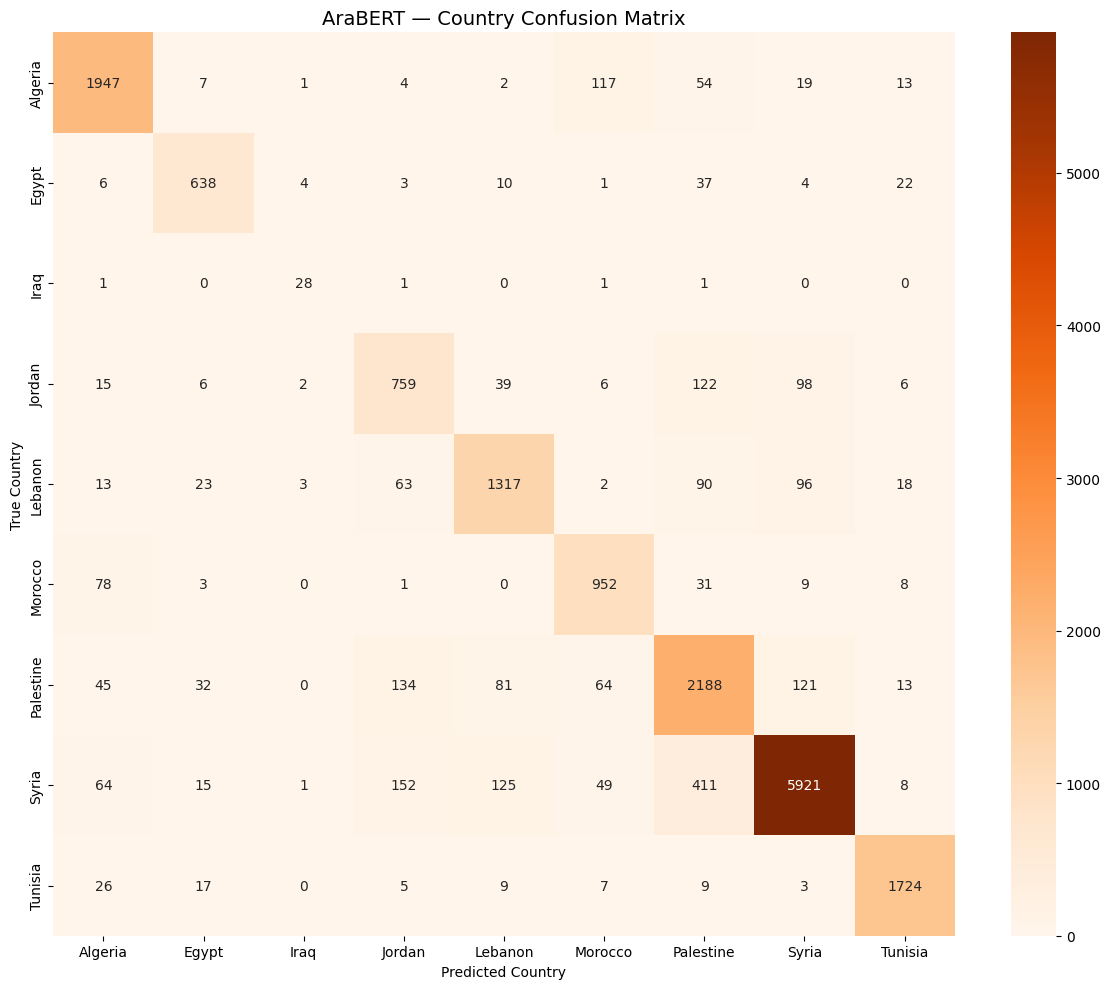

Saved: arabert_country_confusion_matrix.png


In [30]:
c_cm = confusion_matrix(c_true_labels, c_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(c_cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[c_id2label[i] for i in range(NUM_COUNTRY_LABELS)],
            yticklabels=[c_id2label[i] for i in range(NUM_COUNTRY_LABELS)])
plt.title("AraBERT — Country Confusion Matrix", fontsize=14)
plt.ylabel("True Country"); plt.xlabel("Predicted Country")
plt.tight_layout()
plt.savefig("arabert_country_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: arabert_country_confusion_matrix.png")

In [31]:
c_results = {
    "model":       f"{MODEL_DISPLAY_NAME} (Country)",
    "task":        "country",
    "accuracy":    float(c_acc),
    "f1_weighted": float(c_f1_w),
    "f1_macro":    float(c_f1_m),
    "report":      classification_report(
        c_true_labels, c_preds,
        target_names=[c_id2label[i] for i in range(NUM_COUNTRY_LABELS)],
        output_dict=True
    )
}
with open("arabert_country_results.json", "w") as f:
    json.dump(c_results, f, indent=2)
print("Country results saved to arabert_country_results.json")

c_trainer.save_model("./arabert_country_model")
tokenizer.save_pretrained("./arabert_country_model")
print("Country model saved to ./arabert_country_model")

Country results saved to arabert_country_results.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Country model saved to ./arabert_country_model


FINAL COMPARISON: Region vs Country Classification
                     Accuracy  F1 Weighted  F1 Macro
Task                                                
Region (6 classes)   0.909430     0.915640  0.743668
Country (9 classes)  0.864228     0.865789  0.838780


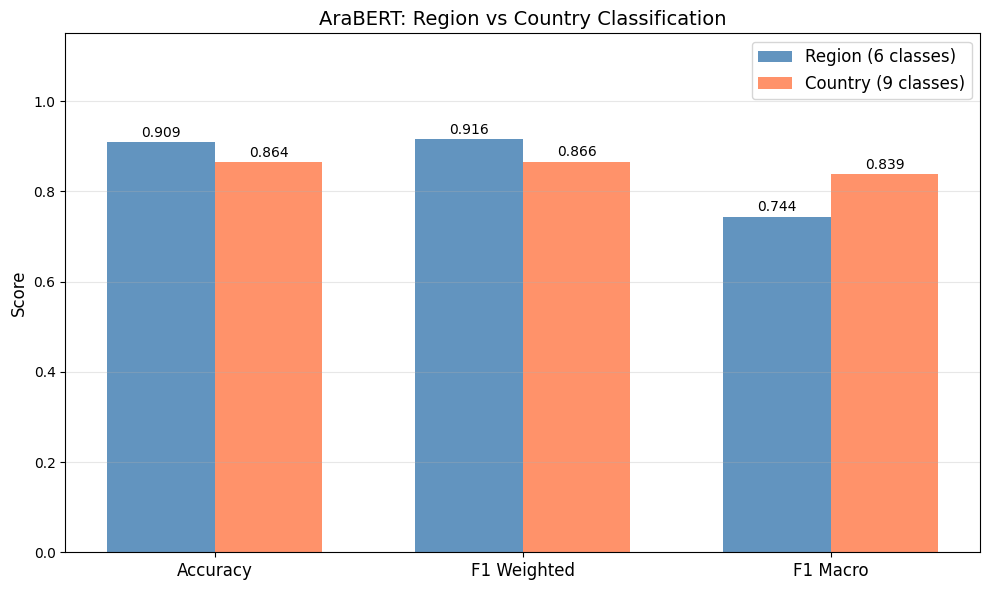

Saved: arabert_region_vs_country.png


In [32]:
print("=" * 60)
print("FINAL COMPARISON: Region vs Country Classification")
print("=" * 60)

# Load region results from saved file
with open("arabert_results.json") as f:
    region_res = json.load(f)

summary = pd.DataFrame({
    "Task":        ["Region (6 classes)", "Country (9 classes)"],
    "Accuracy":    [region_res["accuracy"],    c_acc],
    "F1 Weighted": [region_res["f1_weighted"], c_f1_w],
    "F1 Macro":    [region_res["f1_macro"],    c_f1_m],
}).set_index("Task")
print(summary.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
w = 0.35
metrics_labels = ["Accuracy", "F1 Weighted", "F1 Macro"]
r_vals = [region_res["accuracy"], region_res["f1_weighted"], region_res["f1_macro"]]
c_vals = [c_acc, c_f1_w, c_f1_m]

bars1 = ax.bar(x - w/2, r_vals, w, label="Region (6 classes)",  color="steelblue", alpha=0.85)
bars2 = ax.bar(x + w/2, c_vals, w, label="Country (9 classes)", color="coral",     alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("AraBERT: Region vs Country Classification", fontsize=14)
ax.legend(fontsize=12); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("arabert_region_vs_country.png", dpi=150)
plt.show()
print("Saved: arabert_region_vs_country.png")